# Forest Plot: Effect of Restaurant Name Keywords on Inspection SCORE

Pure visualization notebook: loads the coefficient table and model-ready data saved by `02_analysis.ipynb` (which fits one shared OLS model of SCORE on cuisine group, restaurant-name keywords, and zip-code income quartile) and draws the name-keyword slice of that model. See `03a_cuisine_forest_plot.ipynb` and `03c_income_forest_plot.ipynb` for the other two predictor groups.

**Takes in:** `output/shared_model_coefficients.csv`, `data/model_ready_inspections.csv` (both written by `02_analysis.ipynb`)

**Outputs:** `output/forest_plot_keywords.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import utils

## Load saved model results

In [2]:
coef_table = utils.load_model_coefficients()
model_ready = pd.read_csv(utils.MODEL_READY_PATH)
print(f"Loaded {len(coef_table)} model coefficients and {len(model_ready):,} model-ready rows")

Loaded 27 model coefficients and 131,466 model-ready rows


## Forest plot: name keywords

Coefficients (95% CI) for each restaurant-name keyword indicator, sorted by absolute effect size. Each coefficient is the SCORE difference for restaurants whose name contains that keyword vs. restaurants whose name does not. Blue = higher SCORE (worse), red = lower SCORE (better).

Saved forest plot to /Users/ethan/qss20-nyc-restaurant-inspections/output/forest_plot_keywords.png


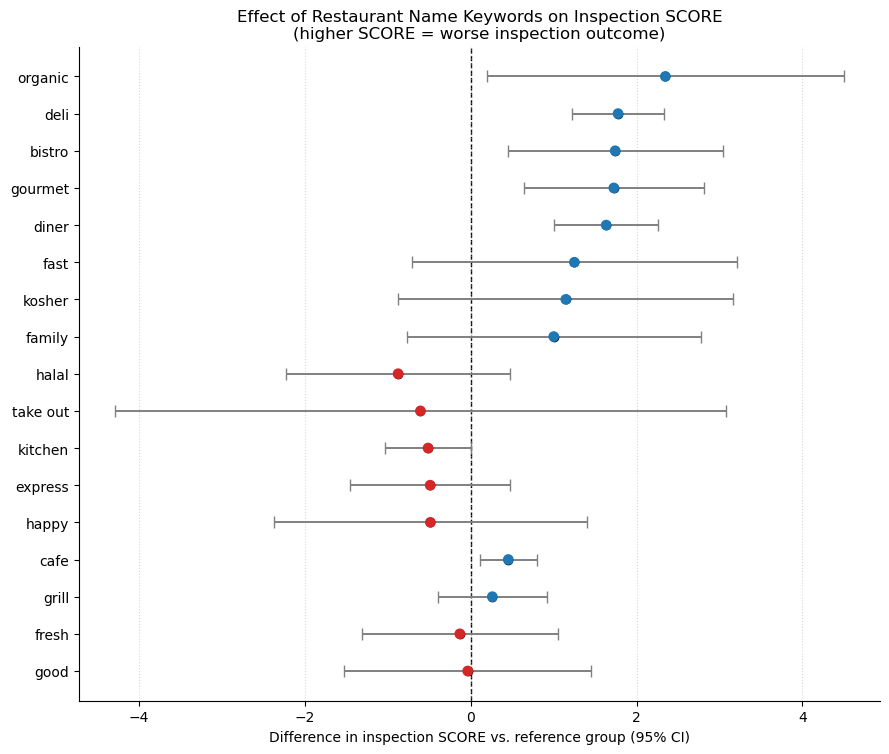

,label,coef,ci_low,ci_high,abs_coef
0,good,-0.036808,-1.526319,1.452703,0.036808
1,fresh,-0.131994,-1.310769,1.046781,0.131994
2,grill,0.260347,-0.400946,0.921640,0.260347
3,cafe,0.452970,0.109517,0.796423,0.452970
4,happy,-0.487330,-2.375119,1.400459,0.487330
5,express,-0.489751,-1.457086,0.477584,0.489751
6,kitchen,-0.515410,-1.030831,0.000010,0.515410
7,take out,-0.606843,-4.288891,3.075206,0.606843
8,halal,-0.876836,-2.224492,0.470820,0.876836
9,family,1.001167,-0.772123,2.774458,1.001167


In [3]:
utils.forest_plot(
    coef_table,
    prefix="name_",
    label_fn=lambda n: n.replace("name_", "").replace("_", " "),
    title="Effect of Restaurant Name Keywords on Inspection SCORE\n"
          "(higher SCORE = worse inspection outcome)",
    save_path=f"{utils.OUTPUT_DIR}/forest_plot_keywords.png",
)